In [57]:
from pydantic import BaseModel
from langgraph.graph import StateGraph,START,END

In [58]:
class GreetState(BaseModel):
    message:str=""

In [59]:
graph=StateGraph(GreetState)

In [60]:
### Nodes - Python Functions
def Greet(state:GreetState):
    state.message=f"Hello, {state.message}!"
    return state

def upper_case(state:GreetState):
    state.message=state.message.upper()
    return state

In [61]:
graph.add_node("Greet",Greet)

In [63]:
graph.add_node("upper_case",upper_case)

In [64]:
graph.add_edge(START,"Greet")
graph.add_edge("Greet","upper_case")
graph.add_edge("upper_case",END)

In [65]:
final=graph.compile()

In [66]:
res=final.invoke({"message": "Alice"})
res

{'message': 'HELLO, ALICE!'}

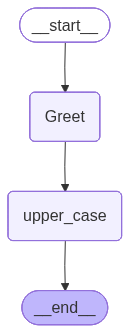

In [67]:
from IPython.display import Image
Image(final.get_graph().draw_mermaid_png())